# Análise de Fatores de Risco para Diabetes
### Projeto Final PCD

**Introdução**: Este projeto realiza uma análise exploratória do Pima Indians Diabetes Database, disponibilizado pelo National Institute of Diabetes and Digestive and Kidney Diseases e hospedado no UCI Machine Learning Repository. O dataset contém informações clínicas de 768 pacientes do sexo feminino, com 8 variáveis (glicose, IMC, pressão arterial, idade, espessura da prega cutânea, insulina, gestação e histórico familiar) e uma coluna-alvo indicando o diagnóstico de diabetes. 

**Objetivo:** Identificar quais características clínicas estão mais associadas ao diagnóstico de diabetes, comparando os perfis de pacientes dos dois grupos por meio de estatísticas descritivas e visualizações.

**Dataset:** Pima Indians Diabetes Database - 768 pacientes, 8 variáveis clínicas.

---

## Importando as bibliotecas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Carregando os dados

Nesta célula a variável `url` guarda o endereço do arquivo CSV com as informações das pacientes e, em seguida, transforma em uma tabela. O número de linhas e colunas é determinado, e temos acesso as 5 primeiras linhas da tabela.

In [2]:
url = 'https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv'
df = pd.read_csv(url)

print(f'Linhas: {df.shape[0]} | Colunas: {df.shape[1]}')
df.head()

Linhas: 768 | Colunas: 9


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


**O que significa cada coluna?**

| Coluna | Significado |
|---|---|
| `Pregnancies` | Número de gestações |
| `Glucose` | Nível de glicose no sangue |
| `BloodPressure` | Pressão arterial |
| `SkinThickness` | Espessura da prega cutânea |
| `Insulin` | Nível de insulina |
| `BMI` | Índice de Massa Corporal (IMC) |
| `DiabetesPedigreeFunction` | Histórico familiar de diabetes |
| `Age` | Idade |
| `Outcome` | **1 = tem diabetes / 0 = não tem** |

## Conhecendo os dados

Resumo estatístico: média, mínimo e máximo de cada coluna, desvio padrão, primeiro quartil, mediana e terceiro quartil.

In [3]:
df.describe().round(1)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.0,768.0,768.0,768.0,768.0,768.0,768.0,768.0,768.0
mean,3.8,120.9,69.1,20.5,79.8,32.0,0.5,33.2,0.3
std,3.4,32.0,19.4,16.0,115.2,7.9,0.3,11.8,0.5
min,0.0,0.0,0.0,0.0,0.0,0.0,0.1,21.0,0.0
25%,1.0,99.0,62.0,0.0,0.0,27.3,0.2,24.0,0.0
50%,3.0,117.0,72.0,23.0,30.5,32.0,0.4,29.0,0.0
75%,6.0,140.2,80.0,32.0,127.2,36.6,0.6,41.0,1.0
max,17.0,199.0,122.0,99.0,846.0,67.1,2.4,81.0,1.0


O resumo estatístico revela alguns padrões importantes. A variável **Glucose** apresenta média de 120,9 mg/dL, com valores que vão de 0 a 199, os zeros são biologicamente impossíveis e provavelmente representam dados ausentes registrados incorretamente. O terceiro quartil está em 140 mg/dL, o que significa que 25% das pacientes já se encontram na faixa considerada de alto risco para diabetes.


Em seguida, ocorre a contagem de quantas pacientes têm ou não têm diabetes, a partir da coluna Outcome. Essa distribuição acontece para conhecer os dados antes de separar definitivamente os grupos.

In [4]:
contagem = df['Outcome'].value_counts()
print('Sem diabetes (0):', contagem[0])
print('Com diabetes (1):', contagem[1])

Sem diabetes (0): 500
Com diabetes (1): 268


Das 768 pacientes do dataset, **500 não têm diabetes (65,1%)** e **268 têm diabetes (34,9%)**. Essa proporção é útil para contextualizar os dados: há quase o dobro de casos negativos em relação aos positivos.

## Separando os dois grupos

Com a distribuição conhecida, as variáveis criam dois DataFrames separados que serão utilizados nas análises seguintes. 

In [5]:
com_diabetes    = df[df['Outcome'] == 1]
sem_diabetes    = df[df['Outcome'] == 0]

print('Pacientes com diabetes:', len(com_diabetes))
print('Pacientes sem diabetes:', len(sem_diabetes))

Pacientes com diabetes: 268
Pacientes sem diabetes: 500


A função a seguir recebe uma tabela filtrada e um nome a exibir, percorre a lista de colunas selecionadas e calcula a média de cada uma para os grupos com e sem diabetes.

In [6]:
def resumo_grupo(grupo, nome):
    """
    Exibe um resumo estatistico de um grupo de pacientes.
    Args:
        grupo (DataFrame): tabela filtrada com as pacientes do grupo,
                           derivada do dataframe df gerado pela leitura
                           do arquivo diabetes.csv.
                        
        nome  (str)      : nome do grupo para exibir no cabecalho
                        
    Returns:
       Apenas imprime o resumo na tela
    """
    
    print(f'--- {nome} ---')
    print(f'Total de pacientes: {len(grupo)}')
    for col in ['Glucose', 'BMI', 'Age', 'BloodPressure']:
        print(f'  {col}: {grupo[col].mean():.1f}')

In [7]:
resumo_grupo(sem_diabetes, 'Sem Diabetes')
resumo_grupo(com_diabetes, 'Com Diabetes')

--- Sem Diabetes ---
Total de pacientes: 500
  Glucose: 110.0
  BMI: 30.3
  Age: 31.2
  BloodPressure: 68.2
--- Com Diabetes ---
Total de pacientes: 268
  Glucose: 141.3
  BMI: 35.1
  Age: 37.1
  BloodPressure: 70.8


**Glucose**, **BMI** e **Age** estão entre as variáveis com maior associação ao diagnóstico de diabetes na literatura médica e, como veremos nas visualizações, também se destacam nesta análise. A **BloodPressure** entra como comparação interessante, apesar de ser frequentemente associada a doenças crônicas, sua diferença entre os grupos será visivelmente menor do que as demais.

## Visualizações

A variável `comparacao` armazea as médias de cada coluna e arredonda seu valor para uma casa decimal.

In [8]:
colunas = ['Glucose', 'BMI', 'Age', 'BloodPressure', 'Insulin']

comparacao = pd.DataFrame({
    'Sem Diabetes': sem_diabetes[colunas].mean().round(1),
    'Com Diabetes': com_diabetes[colunas].mean().round(1)
})

A variável `ax` guarda o gráfico de barras e o `ax.containers` agupa as barras por grupo, e para cada barra é aplicada a textura correspondente.

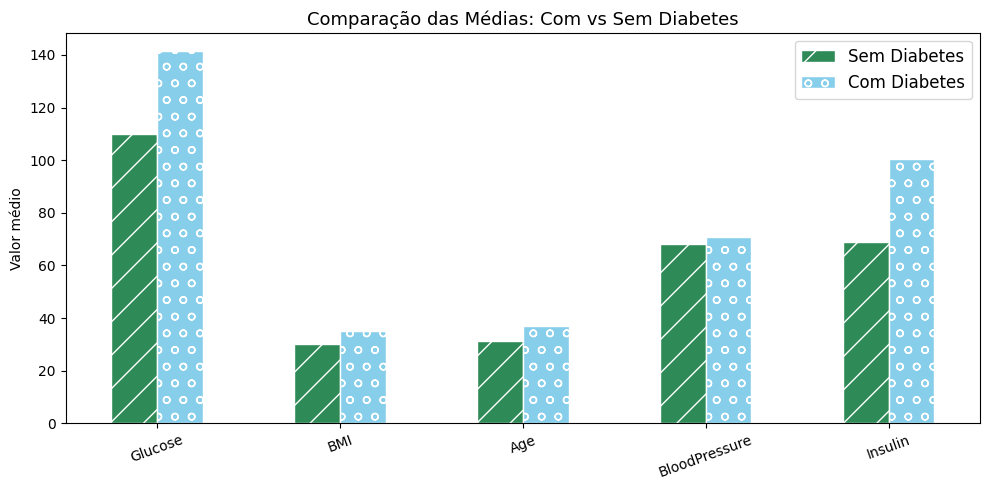

In [9]:
ax = comparacao[['Sem Diabetes', 'Com Diabetes']].plot(
    kind='bar',
    figsize=(10, 5),
    color=['seagreen', 'skyblue'],
    edgecolor='white'
)

hatches = ['/', 'o']
for i, container in enumerate(ax.containers):
    for bar in container:
        bar.set_hatch(hatches[i])

plt.title('Comparação das Médias: Com vs Sem Diabetes', fontsize=13)
plt.ylabel('Valor médio')
plt.xticks(rotation=20)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

O gráfico de barras torna visível uma diferença consistente entre os dois grupos na maioria das variáveis analisadas. A **glicose** apresenta a maior disparidade relativa, com média visivelmente mais alta entre pacientes com diabetes. O **IMC** e a **idade** também se destacam, enquanto a **pressão arterial** mostra a menor diferença entre os grupos, sugerindo que ela, isoladamente, pode ser um fator menos determinante para o diagnóstico.

A função da célula a seguir recebe o nome de uma coluna e gera um histograma comparando os dois grupos. A função é chamada três vezes logo abaixo, uma para cada variável.

In [10]:
def plotar_histograma(coluna):
    """
    Plota gráfico de Glucose, Age ou BMI
    Args:
        coluna (str): nome da coluna a ser visualizada,
                      deve ser uma das colunas presentes 
                      no diabetes.csv
        Returns:
        Apenas exibe o gráfico na tela.
    """
    
    plt.figure(figsize=(8, 4))
    plt.hist(sem_diabetes[coluna], bins=20, alpha=0.9, color='seagreen', label='Sem Diabetes', hatch='/', ec='white')
    plt.hist(com_diabetes[coluna], bins=20, alpha=0.7, color='skyblue', label='Com Diabetes', hatch='o', ec='white')
    plt.title(f'Distribuição de {coluna}')
    plt.xlabel(coluna)
    plt.ylabel('Número de Pacientes')
    plt.legend(fontsize=12)
    plt.show()

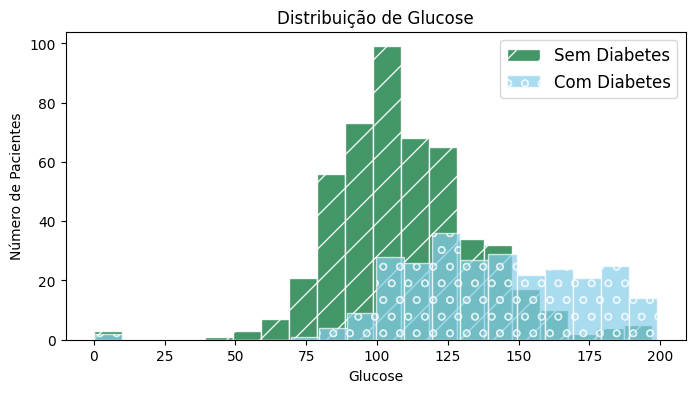

In [11]:
plotar_histograma('Glucose')

A distribuição de glicose das pacientes **com diabetes** se desloca claramente para a direita, com maior concentração de valores acima de 140 mg/dL. Já as pacientes **sem diabetes** se concentram na faixa entre 80 e 120 mg/dL. 

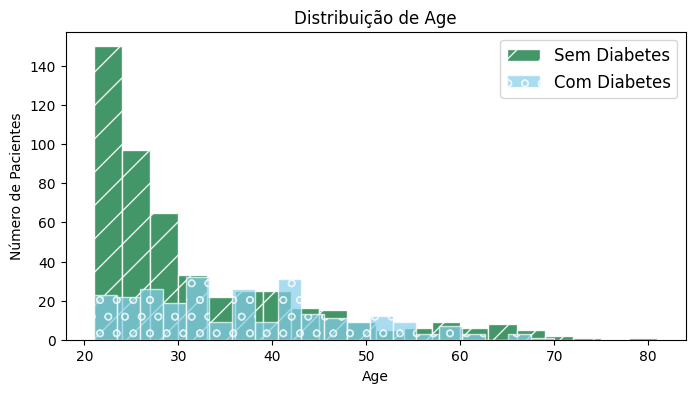

In [12]:
plotar_histograma('Age')

Pacientes com diabetes tendem a ser mais velhas: a distribuição do grupo positivo se estende mais para idades acima de 40 anos, enquanto o grupo sem diabetes concentra a maior parte das pacientes entre 20 e 30 anos. Isso sugere que a idade é um fator de risco relevante, mas não determinante de forma isolada.

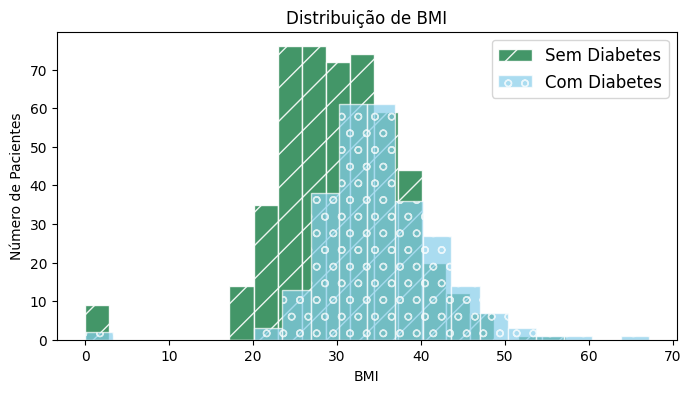

In [13]:
plotar_histograma('BMI')

As distribuições de IMC dos dois grupos se sobrepõem bastante, mas pacientes com diabetes apresentam uma concentração maior em valores de IMC acima de 30 (faixa de obesidade). O grupo sem diabetes, embora também apresente sobrepeso, tem uma calda mais curta nos valores extremos.

Na célula a seguir, o método `.corr()` calcula a correlação entre todas as colunas, retornando uma tabela onde cada célua indica o quanto duas variáveis estão relacionadas entre si.

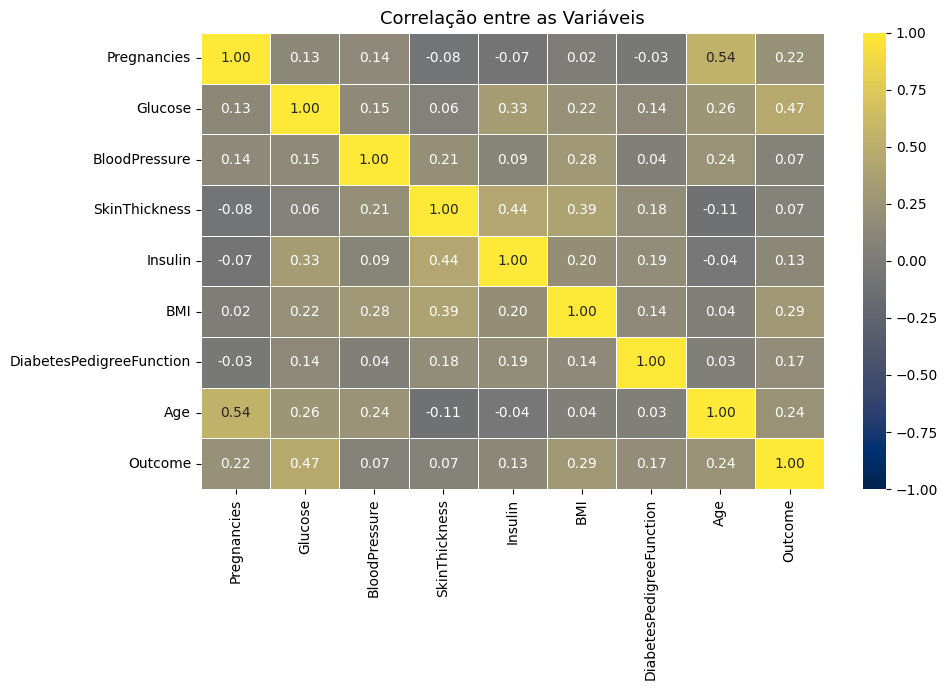

In [14]:
correlacao = df.corr()

plt.figure(figsize=(10,7))
sns.heatmap(
    correlacao, 
    annot=True,
    fmt='.2f',
    cmap = 'cividis',
    vmin=-1, vmax=1,
    linewidths=0.5
)
plt.title('Correlação entre as Variáveis', fontsize=13)
plt.tight_layout()
plt.show()

A variável **Glucose** apresenta a maior correlação com o diagnóstico (`Outcome` ≈ 0.47), confirmando o que os histogramas já indicavam. **BMI** e **Age** também mostram correlações positivas. Outra correlação interessante é **SkinThickness** e **BMI** (0.39), pois ambos são indicadores indiretos de gordura corporal. Para o objetivo deste projeto, a linha mais relevante do heatmap é a última (**Outcome**), pois ela mostra a correlação de cada variável clínica diretamente com o diagnóstico de diabetes. É essa linha que permite ranquear os fatores de risco: Glucose lidera, seguida de BMI, Age e Pregnancies. Vale ressaltar que correlação **não implica causalidade**, esses números indicam associações estatísticas dentro deste dataset específico.

## Análise de alguns fatores

A função recebe a tabela completa, o nome de uma coluna e um valor de corte para filtrar pacientes acima do limite, e calcula a média da coluna Outcome dentro desse grupo para dar a proporção de pacientes com diabetes. Em seguida, a função é chamada duas vezes.

In [15]:
def filtrar_risco(df, coluna, limite):
    """
    Filtra pacientes acima de um limite em uma coluna escolhida
    e calcula a proporcao que tem diabetes nesse grupo.

    Args:
        df      (DataFrame): dataframe principal gerado pela leitura
                             do arquivo diabetes.csv via pd.read_csv()
        coluna  (str)      : nome da coluna a ser filtrada, deve ser 
                             uma das colunas presentes no diabetes.csv
        limite  (float)    : valor de corte, só ficam os pacientes
                             com valor acima desse número

    Returns:
        grupo      (DataFrame): tabela filtrada com as pacientes de risco
        proporcao  (float)    : porcentagem dessas pacientes com diabetes
    """
    grupo = df[df[coluna] > limite]
    proporcao = grupo['Outcome'].mean() * 100
    return grupo, proporcao

In [16]:
grupo, proporcao = filtrar_risco(df, 'Glucose', 140)
print(f'Pacientes com glicose > 140: {len(grupo)}')
print(f'Proporcao com diabetes: {proporcao:.1f}%')

grupo2, proporcao2 = filtrar_risco(df, 'BMI', 35)
print(f'\nPacientes com IMC > 35: {len(grupo2)}')
print(f'Proporcao com diabetes: {proporcao2:.1f}%')

Pacientes com glicose > 140: 192
Proporcao com diabetes: 68.8%

Pacientes com IMC > 35: 244
Proporcao com diabetes: 47.1%


Os limites não foram escolhidos ao acaso: glicose acima de **140 mg/dL** corresponde à faixa de pré-diabetes ou diabetes segundo critérios clínicos estabelecidos, enquanto IMC acima de **35** caracteriza obesidade grau II pela classificação da OMS, estágio associado a risco significativamente elevado de doenças metabólicas. Ao focar nesses subgrupos de risco, é possível observar como a proporção de diagnósticos positivos muda quando comparada ao dataset completo, onde 34,9% das pacientes têm diabetes.

## Conclusão

A análise exploratória do Pima Indians Diabetes Database permitiu identificar
padrões relevantes entre as variáveis clínicas e o diagnóstico de diabetes
nas 768 pacientes do dataset.

O principal ponto do projeto foi a centralidade da **glicose** como fator
de risco. Essa variável se destacou de forma consistente em todas as etapas
da análise:

- No **heatmap de correlação**, Glucose apresentou a maior correlação com
a variável Outcome, indicando ser a característica clínica mais associada
ao diagnóstico de diabetes no dataset;
- Nos **histogramas comparativos**, a distribuição de glicose das pacientes
com diabetes se deslocou visivelmente para valores mais altos em relação
ao grupo sem diabetes, evidenciando uma diferença clara entre os dois grupos;
- Na **análise de risco**, a função `filtrar_risco()` revelou uma alta
proporção de diagnósticos positivos entre pacientes com glicose acima de 140,
reforçando que níveis elevados de glicose estão fortemente associados
à presença da doença.

Esses resultados são coerentes com o conhecimento médico estabelecido:
a hiperglicemia, elevação do nível de glicose no sangue, é justamente
o principal marcador clínico utilizado no diagnóstico do diabetes mellitus. 

## Referências

**Dataset**

SMITH, J. W. et al. Using the ADAP learning algorithm to forecast the onset of diabetes mellitus.
**Proceedings of the Annual Symposium on Computer Application in Medical Care**, Washington, p. 261–265, 1988.

NATIONAL INSTITUTE OF DIABETES AND DIGESTIVE AND KIDNEY DISEASES.
**Pima Indians Diabetes Database**. UCI Machine Learning Repository, 1988.
Disponível em: https://archive.ics.uci.edu/dataset/34/diabetes. Acesso em: 01 jun. 2026.

---

**Bibliotecas utilizadas**

MCKINNEY, W. Data structures for statistical computing in Python.
**Proceedings of the 9th Python in Science Conference**, Austin, v. 445, p. 56–61, 2010.

HUNTER, J. D. Matplotlib: a 2D graphics environment.
**Computing in Science & Engineering**, New York, v. 9, n. 3, p. 90–95, maio/jun. 2007.

WASKOM, M. L. Seaborn: statistical data visualization.
**Journal of Open Source Software**, v. 6, n. 60, p. 3021, 2021.

---
**Conteúdo de aula**

ALMEIDA, James Moraes de. **Pandas**. Campinas: Ilum Escola de Ciência (CNPEM), 2026b. Notebook Jupyter (material didático não publicado).

---

**IA** 

O desenvolvimento deste projeto contou com o auxílio do assistente de inteligência artificial Claude (Anthropic), utilizado como ferramenta de suporte para esclarecimento de dúvidas sobre o código.
https://claude.ai/share/b9893f3a-3d0e-4125-9bfd-81e677cc8e8d 
